# 04 — Model C: Exchange Recommendations

Given a return reason code, recommend the best exchange candidates to offer the customer.

**Two-stage design**:
1. Heuristic filter by reason code (fast, interpretable, ~70% of cases)
2. Feature-weighted scoring on filtered candidates (price proximity + popularity)

**Why heuristics first?** For size/color mismatches, the right answer is
obvious — up-size or same-style different color. An ML model adds no value here
and removes explainability.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[2] / "src"))   # commerce-ml-lab/src  (shared lib)
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))   # 02_returns_intelligence/src
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from commerce_ml.viz.plotting import apply_style, PALETTE
from returns.exchange import ExchangeRecommender, heuristic_candidates, score_candidates, build_catalog
apply_style()
RESULTS = Path("../results"); RESULTS.mkdir(exist_ok=True)

customers = pd.read_parquet(RESULTS / "customers.parquet")
orders    = pd.read_parquet(RESULTS / "orders.parquet")
returns   = pd.read_parquet(RESULTS / "returns.parquet")
print(f"Orders: {len(orders):,}  |  Returns with exchange requests: {returns['exchange_requested'].sum():,}")

Orders: 70,806  |  Returns with exchange requests: 2,565


In [2]:
er = ExchangeRecommender()
er.fit(orders)
print(f"Catalog: {len(er.catalog_):,} items across {er.catalog_['category'].nunique()} categories")
print(er.catalog_.groupby("category")[["popularity","avg_price"]].mean().round(1))

Catalog: 1,500 items across 5 categories
             popularity  avg_price
category                          
apparel           102.4       68.1
beauty             29.4       36.6
electronics        58.9      189.0
footwear           59.8       99.3
home_decor         44.0       57.6


## Rule coverage by reason code

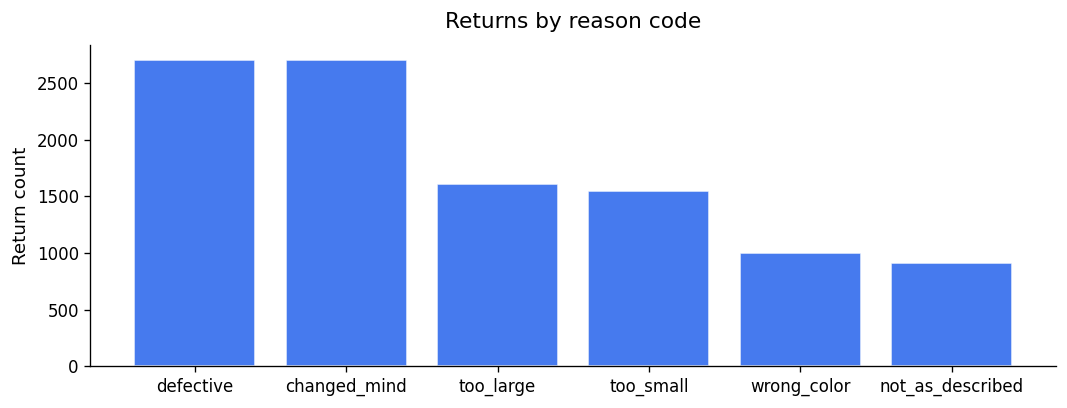

reason_code
defective           2706
changed_mind        2704
too_large           1613
too_small           1544
wrong_color         1001
not_as_described     908
Name: count, dtype: int64


In [3]:
reason_counts = returns["reason_code"].value_counts()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(reason_counts.index, reason_counts.values, color=PALETTE[0], alpha=0.85, edgecolor="white")
ax.set_ylabel("Return count"); ax.set_title("Returns by reason code")
plt.tight_layout(); plt.savefig(RESULTS / "exchange_reason_codes.png", dpi=120); plt.show()
print(reason_counts)

## Example recommendations by reason code

In [4]:
print("Example exchange recommendations:\n")
examples = [
    ("apparel_042",     "too_small",       75.0),
    ("footwear_018",    "defective",       110.0),
    ("apparel_099",     "wrong_color",     55.0),
    ("electronics_025", "changed_mind",    220.0),
    ("beauty_007",      "not_as_described", 40.0),
]
for item_id, reason, price in examples:
    recs = er.recommend(item_id, reason, price, top_k=3)
    rule = recs["rule_applied"].iloc[0] if len(recs) > 0 else "no candidates"
    print(f"  Item: {item_id}  Reason: {reason}")
    print(f"  Rule: {rule}")
    if len(recs) > 0:
        print(f"  Top candidates: {', '.join(recs['item_id'].tolist())}")
    print()

Example exchange recommendations:

  Item: apparel_042  Reason: too_small
  Rule: Same category (size boundary reached)
  Top candidates: apparel_000, apparel_004, apparel_006

  Item: footwear_018  Reason: defective
  Rule: no candidates

  Item: apparel_099  Reason: wrong_color
  Rule: Same style, available colors
  Top candidates: apparel_000, apparel_004, apparel_006

  Item: electronics_025  Reason: changed_mind
  Rule: Same category (electronics), top by popularity
  Top candidates: electronics_126, electronics_248, electronics_079

  Item: beauty_007  Reason: not_as_described
  Rule: Same category (beauty), top by popularity
  Top candidates: beauty_155, beauty_138, beauty_024



## Batch recommendations and exchange acceptance rate estimate

In [5]:
exchange_returns = returns[returns["exchange_requested"]].copy()
batch_recs = er.recommend_batch(exchange_returns.head(200), orders, customers, top_k=3)
print(f"Generated {len(batch_recs):,} recommendations for {batch_recs['return_id'].nunique()} returns")
print(f"Avg score (rank-1): {batch_recs[batch_recs['rank']==1]['score'].mean():.3f}")
print(f"\nRule coverage:")
print(batch_recs[batch_recs['rank']==1]['rule_applied'].value_counts())

er.save(RESULTS / "exchange_model.pkl")
print("\nExchange recommender saved to results/exchange_model.pkl")

Generated 384 recommendations for 128 returns
Avg score (rank-1): 0.915

Rule coverage:
rule_applied
Same category (size boundary reached)             66
Same category (electronics), top by popularity    18
Same style, available colors                      16
Same category (apparel), top by popularity        12
Same category (footwear), top by popularity        9
Same category (beauty), top by popularity          7
Name: count, dtype: int64

Exchange recommender saved to results/exchange_model.pkl
